In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [31]:
df = pd.read_csv('data.csv')

df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,Unknown,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


# Problem 1

In [32]:
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [33]:
imputer = SimpleImputer(strategy='median')

X_train[['Age', 'Salary']] = imputer.fit_transform(X_train[['Age', 'Salary']])
X_test[['Age', 'Salary']] = imputer.transform(X_test[['Age', 'Salary']])

In [34]:
X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target
29,34.0,20541.0,46632.0,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,Type1,NaN,S,Male,231.94
535,35.0,46050.0,71684.0,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,NaN,NaN,Q,Female,228.30
695,31.0,8652.0,85790.0,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,NaN,NaN,C,Male,266.84
557,29.0,93707.0,52109.0,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,NaN,NaN,S,Female,221.75
836,53.0,41021.0,61257.0,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,NaN,NaN,S,Female,261.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454.0,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,Type1,NaN,S,Female,161.48
270,52.0,55063.0,52856.0,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,NaN,NaN,C,Female,303.58
860,37.0,7655.0,54442.0,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,Type1,NaN,S,Female,327.19
435,35.0,48894.0,50286.0,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,Type2,NaN,S,Male,311.50


# Problem 02:

In [35]:
df.isnull().sum()

Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64

In [36]:
percentage_of_missing = (df.isnull().sum() / len(df)) * 100

print(percentage_of_missing)

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64


# Problem 3:

In [37]:
X_train['Temperature'] = X_train['Temperature'].replace('Unknown', np.nan)

Temperature_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

Temperature_imputer.fit(X_train[['Temperature']])

X_train['Temperature'] = Temperature_imputer.transform(X_train[['Temperature']]).ravel()


In [41]:
X_train['Temperature'].isnull().sum()

np.int64(0)

# Problem 4:

In [42]:
Diagnosis_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

Diagnosis_imputer.fit(X_train[['Diagnosis']])

X_train[['Diagnosis', 'Diagnosis_missing_indicator']] = Diagnosis_imputer.transform(X_train[['Diagnosis']])
X_test[['Diagnosis', 'Diagnosis_missing_indicator']] = Diagnosis_imputer.transform(X_test[['Diagnosis']])

In [43]:
X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosis_missing_indicator
29,34.0,20541.0,46632.0,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,Type1,NaN,S,Male,231.94,False
535,35.0,46050.0,71684.0,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,Missing,NaN,Q,Female,228.30,True
695,31.0,8652.0,85790.0,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,Missing,NaN,C,Male,266.84,True
557,29.0,93707.0,52109.0,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,Missing,NaN,S,Female,221.75,True
836,53.0,41021.0,61257.0,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,Missing,NaN,S,Female,261.28,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454.0,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,Type1,NaN,S,Female,161.48,False
270,52.0,55063.0,52856.0,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,Missing,NaN,C,Female,303.58,True
860,37.0,7655.0,54442.0,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,Type1,NaN,S,Female,327.19,False
435,35.0,48894.0,50286.0,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,Type2,NaN,S,Male,311.50,False


In [44]:
X_train.isnull().sum()

Age                              0
Income                         126
Salary                           0
Rating                          66
Annual_Income                   97
Customer_Support_Calls          62
House_Price                     83
Square_Feet                      0
Temperature                      0
City                            38
Product_Type                     0
Location                         0
Diagnosis                        0
Cabin                          545
Embarked                         2
Gender                           0
Price_Target                     0
Diagnosis_missing_indicator      0
dtype: int64

# Problem 5:

In [45]:
# mean imputer

age_mean = X_train['Age'].mean()

X_train['age_mean_imputer'] = X_train['Age'].fillna(age_mean)
X_test['age_mean_imputer'] = X_test['Age'].fillna(age_mean)

In [46]:
# median imputer

age_median = X_train['Age'].median()

X_train['age_median_imputer'] = X_train['Age'].fillna(age_median)
X_test['age_median_imputer'] = X_test['Age'].fillna(age_median)

In [48]:
X_test

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosis_missing_indicator,age_mean_imputer,age_median_imputer
521,41.0,73315.0,57252.0,3.8,93298.0,4.0,157109.0,2215,20.8,Dhaka,Unknown,A,Type1,NaN,S,Male,223.00,False,41.0,41.0
737,46.0,178787.0,55297.0,4.8,126876.0,0.0,419358.0,1092,28.7,Dhaka,C,A,Type2,NaN,S,Female,233.71,False,46.0,46.0
740,34.0,6057.0,66301.0,3.3,40303.0,1.0,314431.0,2628,21.9,Dhaka,Unknown,C,Type1,NaN,C,Female,256.23,False,34.0,34.0
660,28.0,51440.0,64413.0,3.4,NaN,2.0,270048.0,2261,25.5,Chittagong,Unknown,B,Type2,NaN,C,Male,236.42,False,28.0,28.0
411,21.0,12169.0,60287.0,2.0,35858.0,0.0,NaN,1717,22.0,Chittagong,A,C,Type3,NaN,S,Male,322.29,False,21.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,36.0,28947.0,62845.0,2.3,15326.0,2.0,267695.0,2301,29.7,Dhaka,B,B,Type2,NaN,S,Male,217.31,False,36.0,36.0
332,35.0,5083.0,21564.0,4.3,63630.0,3.0,428279.0,2197,21.9,Khulna,C,A,Type1,Cabin_C,S,Male,298.54,False,35.0,35.0
208,41.0,23917.0,65271.0,2.7,NaN,0.0,387398.0,2418,21.3,Dhaka,A,A,Type1,Cabin_A,S,Female,244.72,False,41.0,41.0
613,21.0,8060.0,61040.0,3.2,98569.0,NaN,98509.0,2784,24.4,Chittagong,B,B,Type1,NaN,S,Male,192.67,False,21.0,21.0


<Axes: xlabel='age_mean_imputer', ylabel='Density'>

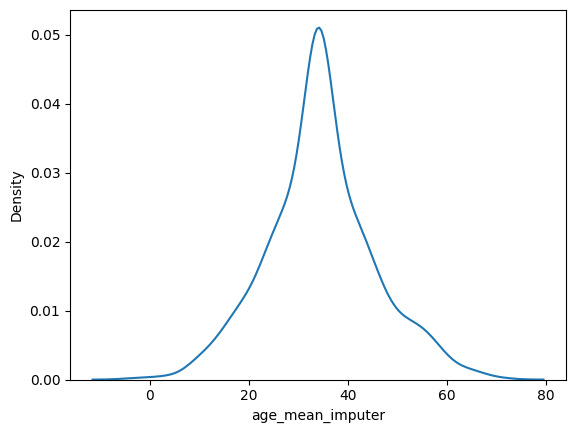

In [49]:
sns.kdeplot(data=X_train, x='age_mean_imputer')

<Axes: xlabel='age_median_imputer', ylabel='Density'>

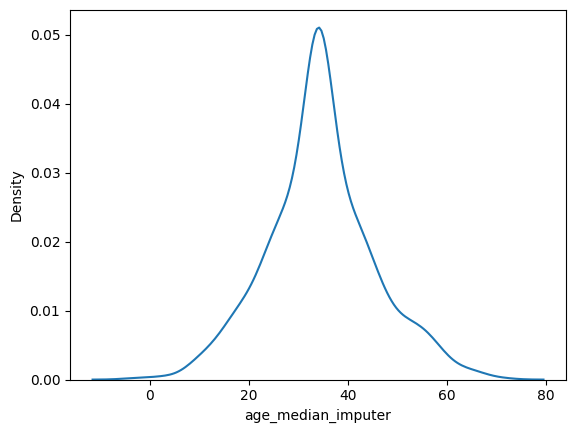

In [50]:
sns.kdeplot(data=X_train, x='age_median_imputer')